# Experiment Results Plotting

This notebook is used to generate plots for the evaluation of different strategies based on the experiment results stored in JSON files.

## 1. Imports

In [1]:
import json
import os
from collections import defaultdict
from math import isnan
import numpy as np
from matplotlib import pyplot as plt


## 2. Configuration
Adjust the variables in this section to control which experiments and strategies are plotted.

In [17]:
aggregate_funtion = np.average
# List of experiment names to load. These should correspond to the JSON file names in the `results` folder.
# experiments = ["paper_evaluation_f1_score_null_strict", "batch_insertion_f1_score_null_strict", "shuffled_columns_f1_score_null_strict"]
experiments = ["paper_evaluation_f1_score_null_strict"]
# Set to a list of strategy names to plot only those, or None to plot all.
strategies_to_consider = [
    # "Llama3_not_finetuned",
    # "Llama3_finetuned_dc",
    # "justine_v0",
    # "justine_optimization_2",
    # "Llama3_3_not_finetuned",
    "justine_3_3_one_prompt",
    # "justine_3_3_retry_with_same_prompt",
    "justine_3_3_retry_with_feedback",
    # "justine_3_3_retry_with_feedback_optimization_1",
    # "justine_3_3_retry_with_feedback_one_shot",
    # "justine_3_3_retry_with_feedback_old_db_prompt",
    "justine_3_3_retry_with_feedback_two_shot",
    "justine_3_3_retry_with_feedback_certainty",
]
# If True, only data points where all strategies have results will be included.
require_same_results = True
# Labels for the plot axes
y_label = ""
if "sparsity" in experiments[0]:
    y_label = "Sparsity"
elif "f1_score" in experiments[0]:
    y_label = "Database F1 Score"
elif "precision" in experiments[0]:
    y_label = "Precision"
elif "recall" in experiments[0]:
    y_label = "Recall"
elif "number_of_tables" in experiments[0]:
    y_label = "Number of tables"
elif "number_of_rows" in experiments[0]:
    y_label = "Number of columns"
elif "standard_deviation_of_rows" in experiments[0]:
    y_label = "Standard deviation of rows"
x_label = (
    "Altered names (%)"
    if "synonyms_used" in experiments[0]
    else (
        "Removed tables (%),\nRemoved columns (%)"
        if "table_and_columns_deleted" in experiments[0]
        else (
            "Removed columns (%)"
            if "columns_deleted" in experiments[0]
            else "Removed tables (%)"
        )
    )
)
# Identifier for data type specific evaluations
data_type_evaluation_identifier = "_only_"

### Plotting Labels and Colors

In [3]:
strategy_labels = {
    "gold_standard": "Gold Standard",
    "Llama3_not_finetuned": "Not fine-tuned\nLlama 3",
    "Llama3_finetuned_all_scenarios": "Fine-tuned Llama 3 (new)",
    "Llama3_finetuned_dc": "Fine-tuned\nLlama 3",
    "Heuristic_exact": "Heuristic (exact)",
    "Heuristic_fuzzy": "Heuristic (fuzzy)",
    "Heuristic_synonyms": "Heuristic (synonyms)",
    "GPT3_5": "GPT-3.5",
    "GPT4o_mini": "GPT-4o mini",
    "GPT4o": "GPT-4o",
    "justine_v0": "JUSTINE with\nfine-tuned Llama 3",
    "justine_optimization_1": "Remap Rows\nOptimization",
    "justine_optimization_2": "JUSTINE with\nfine-tuned Llama 3\nand optimization step",
    "justine_optimization_3": "Remap Rows\n-> Table Matching\nOptimization",
    "justine_optimization_4": "Table Matching\n-> Remap Rows\nOptimization",
    "Llama3_3_not_finetuned": "Not fine-tuned\nLlama 3.3",
    "justine_3_3_one_prompt": "JUSTINE with\nLlama 3.3\n(one prompt)",
    "justine_3_3_retry_with_same_prompt": "Retry with\nadjusted state",
    "justine_3_3_retry_with_feedback": "Retry with\nfeedback",
    "justine_3_3_retry_with_feedback_optimization_1": "Retry with\nfeedback optimization",
    "justine_3_3_retry_with_feedback_one_shot": "Feedback retry\none-shot",
    "justine_3_3_retry_with_feedback_old_db_prompt": "Feedback retry\nold db prompt",
    "justine_3_3_retry_with_feedback_two_shot": "Feedback retry\ntwo-shot",
    "justine_3_3_retry_with_feedback_certainty": "Feedback retry\ncertainty",
}
strategy_colors = {
    "gold_standard": "#BBBBBB",
    "Llama3_finetuned": "#FFFFFF",
    "Llama3_finetuned_all_scenarios": "FFFFFF",
    "Llama3_finetuned_dc": "#4477AA",
    "Llama3_not_finetuned": "#66CCEE",
    "Llama3_3_not_finetuned": "#66CCEE",
    "Heuristic_exact": "#CCBB44",
    "Heuristic_fuzzy": "#EE6677",
    "Heuristic_synonyms": "#AA3377",
    "GPT3_5": "#CCBB44",
    "GPT4o_mini": "#EE6677",
    "GPT4o": "#AA3377",
    "justine_v0": "#AA3377",
    "justine_optimization_1": "#AA3377",
}
ratio_labels = {
    "0.1": r"$r_s \leq 10\%$",
    "0.3": r"$10\% < r_s \leq 30\%$",
    "0.7": r"$30\% < r_s < 70\%$",
    "0.9": r"$70\% \leq r_s < 90\%$",
    "1.0": r"$90\% \leq r_s$",
}
ratio_colors = {
    "0.1": "#4477AA",
    "0.3": "#66CCEE",
    "0.7": "#CCBB44",
    "0.9": "#EE6677",
    "1.0": "#AA3377",
}
experiment_labels = {
    "paper_evaluation": "Paper Evaluation",
    "batch_insertion": "Batch Insertion",
    "shuffled_columns": "Shuffled Columns",
}


## 3. Data Loading

In [4]:
def load_results(
    file_path: str,
    strategies_to_consider: list[str] = None,
    require_same_results: bool = True,
) -> tuple[list[float], dict[str, dict[str, list[float]]]]:
    with open(file_path, encoding="utf-8") as results_file:
        results = json.load(results_file)
    result_collector = (
        defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: [])))
        if data_type_evaluation_identifier in experiments[0]
        else defaultdict(lambda: defaultdict(lambda: []))
    )
    gold_standard_collector = []
    for database, results_per_db in sorted(results.items(), key=lambda x: x[0]):
        strategies = (
            strategies_to_consider if strategies_to_consider else list(results_per_db.keys())
        )
        if "gold_standard" not in strategies:
            strategies.append("gold_standard")
        if require_same_results and any(
            [
                len(results_per_db[s]) == 0
                for s in strategies
                if isinstance(results_per_db[s], dict)
            ]
        ):
            continue
        for strategy in strategies:
            if strategy not in results_per_db:
                continue
            if strategy == "gold_standard":
                # Is only required in sparsity where no data type evaluation is done
                if data_type_evaluation_identifier in experiments[0]:
                    continue
                if isnan(results_per_db[strategy]):
                    continue
                gold_standard_collector.append(results_per_db[strategy])
            else:
                for parameters, result_per_parameters in results_per_db[
                    strategy
                ].items():
                    if require_same_results and any(
                        [
                            parameters not in results_per_db[s]
                            for s in strategies
                            if s != "gold_standard" and s in results_per_db
                        ]
                    ):
                        continue
                    if data_type_evaluation_identifier in experiments[0]:
                        for (
                            data_type_ratio,
                            results_per_ratio,
                        ) in result_per_parameters.items():
                            if isnan(results_per_ratio):
                                continue
                            result_collector[strategy][parameters][
                                data_type_ratio
                            ].append(results_per_ratio)
                    else:
                        if isnan(result_per_parameters):
                            continue
                        result_collector[strategy][parameters].append(
                            result_per_parameters
                        )
    return gold_standard_collector, result_collector


## 4. Plotting Functions

In [5]:
def boxplot_one_parameter_all_strategies(
    gs_results: list[float], results: dict[str, dict[str, list[float]]], parameter: str
):
    values = []
    labels = []
    titles = []
    if "sparsity" in experiments[0] or "number_of_tables" in experiments[0] or "number_of_columns" in experiments[0] or "standard_deviation_of_rows" in experiments[0]:
        print(
            "Gold Standard",
            "Average: ",
            np.average(gs_results),
            ", Std: ",
            np.std(gs_results),
            ", Values:",
            gs_results,
        )
        values.append(gs_results)
        labels.append("Gold Standard")
        titles.append(strategy_labels["gold_standard"])
    for strategy, label in strategy_labels.items():
        if strategy not in results:
            continue
        parameters_values = (
            dict(sorted(results[strategy].items(), key=lambda x: float(x[0])))
            if "_" not in list(results[strategy].keys())[0]
            else dict(
                sorted(
                    results[strategy].items(),
                    key=lambda x: tuple([float(p) for p in x[0].split("_")]),
                )
            )
        )
        print(
            strategy,
            "Average: ",
            np.average(parameters_values[parameter]),
            ", Std: ",
            np.std(parameters_values[parameter]),
            ", Values:",
            parameters_values[parameter],
        )
        values.append(parameters_values[parameter])
        labels.append(label)
    fig, axs = plt.subplots(figsize=(8, 4))
    axs.set_ylabel(y_label)
    if "f1_score" in experiments[0] or "precision" in experiments[0] or "recall" in experiments[0] or "sparsity" in experiments[0]:
        axs.set_ylim(-0.02, 1.02)
    axs.grid(True, axis="y", color="0.9", linestyle="--")
    axs.boxplot(
        values,
        tick_labels=labels,
        showmeans=True,
    )
    fig.tight_layout()
    plt.savefig(
        os.path.join(
            "plots",
            f"{experiments[0]}{'_selected_strategies' if strategies_to_consider else '_all_strategies'}_{parameter}.pdf",
        ),
        format="pdf",
    )
    plt.show()

In [6]:
def boxplot_one_strategy_by_database_source(
    file_path: str,
    strategy: str,
    parameter: str,
):
    with open(file_path, encoding="utf-8") as results_file:
        raw_results = json.load(results_file)

    source_groups = {
        "bird": [],
        "spider": [],
        "spider2": [],
        "wikidb": [],
    }
    source_labels = {
        "bird": "BIRD",
        "spider": "Spider",
        "spider2": "Spider 2",
        "wikidb": "WikiDB",
    }

    for database, results_per_db in sorted(raw_results.items(), key=lambda x: x[0]):
        if strategy not in results_per_db:
            continue
        if not isinstance(results_per_db[strategy], dict):
            continue
        if parameter not in results_per_db[strategy]:
            continue

        source_name = None
        if database.startswith("bird_"):
            source_name = "bird"
        elif database.startswith("spider2_"):
            source_name = "spider2"
        elif database.startswith("spider_"):
            source_name = "spider"
        elif database.startswith("wikidb_"):
            source_name = "wikidb"

        if source_name is None:
            continue

        source_groups[source_name].append(results_per_db[strategy][parameter])

    values = [source_groups[source] for source in source_labels.keys() if source_groups[source]]
    labels = [source_labels[source] for source in source_labels.keys() if source_groups[source]]

    fig, axs = plt.subplots(figsize=(7, 4))
    axs.set_ylabel(y_label)
    axs.set_ylim(-0.02, 1.02)
    axs.grid(True, axis="y", color="0.9", linestyle="--")
    axs.boxplot(values, tick_labels=labels, showmeans=True)
    axs.set_title(f"{strategy_labels.get(strategy, strategy)} by database source")
    fig.tight_layout()
    plt.savefig(
        os.path.join(
            "plots",
            f"{experiments[0]}_{strategy}_by_database_source_{parameter}.pdf",
        ),
        format="pdf",

    )
    plt.show()

In [7]:
def scatter_by_num_columns_tables(
    file_path: str,
    strategy: str,
    parameter: str,
    use_tables: bool = False,
):
    """Scatter: database result vs number of columns, colored by source."""
    with open(file_path, encoding="utf-8") as results_file:
        raw_results = json.load(results_file)

    source_labels = {
        "bird": "BIRD",
        "spider": "Spider",
        "spider2": "Spider 2",
        "wikidb": "WikiDB",
    }
    source_colors = {
        "bird": "#4477AA",
        "spider": "#66CCEE",
        "spider2": "#CCBB44",
        "wikidb": "#EE6677",
    }

    groups = {k: {"x": [], "y": []} for k in source_labels.keys()}

    for database, results_per_db in sorted(raw_results.items(), key=lambda x: x[0]):
        if strategy not in results_per_db:
            continue
        if not isinstance(results_per_db[strategy], dict):
            continue
        if parameter not in results_per_db[strategy]:
            continue

        val = results_per_db[strategy][parameter]
        if isinstance(val, dict):
            continue
        try:
            if isnan(val):
                continue
        except Exception:
            pass

        source_name = None
        if database.startswith("bird_"):
            source_name = "bird"
        elif database.startswith("spider2_"):
            source_name = "spider2"
        elif database.startswith("spider_"):
            source_name = "spider"
        elif database.startswith("wikidb_"):
            source_name = "wikidb"

        if source_name is None:
            continue

        # try to read number of columns from data/<db>/gold_standard_results.json
        num_entities = None
        gs_file_path = os.path.join("data", database, "gold_standard_results.json")
        if os.path.exists(gs_file_path):
            try:
                with open(gs_file_path, encoding="utf-8") as gf:
                    gs_results = json.load(gf)
                
                if use_tables:
                    num_entities = len(gs_results)
                else:
                    num_entities = sum([len(table[0]) for table in gs_results.values()])
            except Exception:
                num_entities = None

        if num_entities is None:
            continue

        groups[source_name]["x"].append(num_entities)
        groups[source_name]["y"].append(val)

    # plot per source to have legend entries
    fig, axs = plt.subplots(figsize=(8, 6))
    for source, data_dict in groups.items():
        if not data_dict["x"]:
            continue
        axs.scatter(
            data_dict["x"],
            data_dict["y"],
            color=source_colors.get(source, "#333333"),
            label=source_labels[source],
            alpha=0.8,
            s=30,
        )

    axs.set_xscale("linear")
    axs.set_xlabel("Number of tables in gold standard database" if use_tables else "Number of columns in gold standard database")
    axs.set_ylabel(y_label)
    axs.set_ylim(-0.02, 1.02)
    axs.grid(True, axis="y", color="0.9", linestyle="--")
    axs.legend()
    fig.tight_layout()
    plt.savefig(
        os.path.join("plots", f"{experiments[0]}_{strategy}_vs_num_{'tables' if use_tables else 'columns'}_{parameter}.pdf"),
        format="pdf",
    )
    plt.show()

In [8]:
def scatter_by_percentage_numerical(
    file_path: str,
    strategy: str,
    parameter: str,
):
    """Scatter: database result vs number of columns, colored by source."""
    with open(file_path, encoding="utf-8") as results_file:
        raw_results = json.load(results_file)

    source_labels = {
        "bird": "BIRD",
        "spider": "Spider",
        "spider2": "Spider 2",
        "wikidb": "WikiDB",
    }
    source_colors = {
        "bird": "#4477AA",
        "spider": "#66CCEE",
        "spider2": "#CCBB44",
        "wikidb": "#EE6677",
    }

    groups = {k: {"x": [], "y": []} for k in source_labels.keys()}

    consider_value = lambda value: value is not None and value != "None" and value != "nan"
    def is_numerical(value):
        try:
            float(value)
            return True
        except Exception:
            return False

    for database, results_per_db in sorted(raw_results.items(), key=lambda x: x[0]):
        if strategy not in results_per_db:
            continue
        if not isinstance(results_per_db[strategy], dict):
            continue
        if parameter not in results_per_db[strategy]:
            continue

        val = results_per_db[strategy][parameter]
        if isinstance(val, dict):
            continue
        try:
            if isnan(val):
                continue
        except Exception:
            pass

        source_name = None
        if database.startswith("bird_"):
            source_name = "bird"
        elif database.startswith("spider2_"):
            source_name = "spider2"
        elif database.startswith("spider_"):
            source_name = "spider"
        elif database.startswith("wikidb_"):
            source_name = "wikidb"

        if source_name is None:
            continue

        # try to read number of columns from data/<db>/gold_standard_results.json
        total_values = None
        numerical_values = None
        gs_file_path = os.path.join("data", database, "gold_standard_results.json")
        if os.path.exists(gs_file_path):
            try:
                with open(gs_file_path, encoding="utf-8") as gf:
                    gs_results = json.load(gf)
                
                total_values = sum([sum([len([value for value in row if consider_value(value)]) for row in table]) for table in gs_results.values()])
                numerical_values = sum([sum([len([value for value in row if consider_value(value) and is_numerical(value)]) for row in table]) for table in gs_results.values()])
            except Exception:
                total_values = None
                numerical_values = None

        if total_values is None or numerical_values is None:
            continue

        percentage_numerical = numerical_values / total_values if total_values > 0 else 0

        groups[source_name]["x"].append(percentage_numerical)
        groups[source_name]["y"].append(val)

    # plot per source to have legend entries
    fig, axs = plt.subplots(figsize=(8, 6))
    for source, data_dict in groups.items():
        if not data_dict["x"]:
            continue
        axs.scatter(
            data_dict["x"],
            data_dict["y"],
            color=source_colors.get(source, "#333333"),
            label=source_labels[source],
            alpha=0.8,
            s=30,
        )
    # add regression line computed across all points
    all_x = []
    all_y = []
    for d in groups.values():
        all_x.extend(d["x"])
        all_y.extend(d["y"])

    axs.set_xscale("linear")
    axs.set_xlabel("Percentage of numerical values in gold standard database")
    axs.set_ylabel(y_label)
    axs.set_ylim(-0.02, 1.02)
    axs.grid(True, axis="y", color="0.9", linestyle="--")

    if len(all_x) >= 2:
        try:
            xs = np.array(all_x, dtype=float)
            ys = np.array(all_y, dtype=float)
            coeffs = np.polyfit(xs, ys, 1)
            poly = np.poly1d(coeffs)
            x_line = np.linspace(xs.min(), xs.max(), 200)
            y_line = poly(x_line)
            axs.plot(x_line, y_line, color="#000000", linewidth=2, label="Regression")
        except Exception:
            pass

    axs.legend()
    fig.tight_layout()
    plt.savefig(
        os.path.join("plots", f"{experiments[0]}_{strategy}_vs_percentage_numerical_values_{parameter}.pdf"),
        format="pdf",
    )
    plt.show()

In [9]:
def boxplot_one_parameter_all_strategies_multiple_scores(
    gs_results: list[float],
    results: dict[str, dict[str, dict[str, list[float]]]],
    parameter: str | list[str],
):
    values = [[] for _ in range(len(results))]
    labels = []
    titles = []
    if "sparsity" in experiments[0]:
        values.append([gs_results])
        labels.append([""])
        titles.append(strategy_labels["gold_standard"])
    for strategy, label in strategy_labels.items():
        if strategy not in list(results.values())[0]:
            continue
        for i, result in enumerate(results.values()):
            parameters_values = (
                dict(sorted(result[strategy].items(), key=lambda x: float(x[0])))
                if not result[strategy].keys().__iter__().__next__().__contains__("_")
                else dict(
                    sorted(
                        result[strategy].items(),
                        key=lambda x: tuple([float(p) for p in x[0].split("_")]),
                    )
                )
            )
            p = parameter if isinstance(parameter, str) else parameter[i]
            print(
                strategy,
                "Average: ",
                np.average(parameters_values[p]),
                ", Std: ",
                np.std(parameters_values[p]),
            )
            values[i].append(parameters_values[p])
        labels.append(label)
    x_base = np.arange(len(labels)) * (len(results) + 1)

    font = {"size": 14}
    plt.rc("font", **font)
    fig, axs = plt.subplots(figsize=(4 * len(results), 4))
    axs.set_ylabel(y_label)
    axs.set_ylim(-0.02, 1.02)
    axs.grid(True, axis="y", color="0.9", linestyle="--")
    axs.set_xticks(x_base + (len(results) - 1) / 2)
    axs.set_xticklabels(labels)

    for i in range(len(results)):
        color = list(ratio_colors.values())[i]
        axs.boxplot(
            values[i],
            positions=x_base + i,
            showmeans=True,
            manage_ticks=False,
            boxprops=dict(color=color),
            whiskerprops=dict(color=color),
            capprops=dict(color=color),
        )

        if "strict" in experiments[i] and "null" in experiments[i]:
            label = "Strict incl. NULL"
        elif "strict" in experiments[i]:
            label = "Strict excl. NULL"
        elif "null" in experiments[i]:
            label = "Loose incl. NULL"
        else:
            label = "Loose excl. NULL"
        axs.plot(
            [],
            [],
            color=color,
            marker="s",
            markersize=8,
            linestyle="None",
            label=label,
        )

    axs.legend()
    fig.tight_layout()
    plt.savefig(
        os.path.join(
            "plots",
            f"multiple_scores{'_selected_strategies' if strategies_to_consider else '_all_strategies'}_{parameter}.pdf",
        ),
        format="pdf",
    )
    plt.show()


In [10]:
def boxplot_one_parameter_one_strategy_multiple_experiments(
    gs_results: list[float],
    results: dict[str, dict[str, dict[str, list[float]]]],
    experiments: list[str],
    strategy: str | list[str],
    parameter: str | list[str],
):
    values = []
    labels = []
    titles = []
    if "sparsity" in experiments[0]:
        values.append(gs_results)
        labels.append([""])
        titles.append(strategy_labels["gold_standard"])
    for i, experiment in enumerate(experiments):
        if experiment not in results:
            continue

        result = results[experiment]
        s = strategy if isinstance(strategy, str) else strategy[i]
        p = parameter if isinstance(parameter, str) else parameter[i]

        parameters_values = dict(
            sorted(
                result[s].items(),
                key=lambda x: tuple([float(p) for p in x[0].split("_")]),
            )
        )
        print(
            s,
            "Average: ",
            np.average(parameters_values[p]),
            ", Std: ",
            np.std(parameters_values[p]),
            ", Values:",
            parameters_values[p],
        )
        values.append(parameters_values[p])
        label = experiment_labels.get(experiment.split("_f1_score")[0], experiment)
        labels.append(label)

    fig, axs = plt.subplots(figsize=(8, 4))
    axs.set_ylabel(y_label)
    if "f1_score" in experiments[0] or "precision" in experiments[0] or "recall" in experiments[0] or "sparsity" in experiments[0]:
        axs.set_ylim(-0.02, 1.02)
    axs.grid(True, axis="y", color="0.9", linestyle="--")
    axs.boxplot(
        values,
        tick_labels=labels,
        showmeans=True,
    )
    fig.tight_layout()
    plt.savefig(
        os.path.join(
            "plots",
            f"multiple_experiments_{strategy if isinstance(strategy, str) else 'multiple_strategies'}_{parameter}.pdf",
        ),
        format="pdf",
    )
    plt.show()


In [11]:
def boxplot_parameters_all_strategies(
    gs_results: list[float], results: dict[str, dict[str, list[float]]]
):
    values = []
    labels = []
    titles = []
    if "sparsity" in experiments[0]:
        values.append([gs_results])
        labels.append([""])
        titles.append(strategy_labels["gold_standard"])
    for strategy, label in strategy_labels.items():
        if strategy not in results:
            continue
        parameters_values = (
            dict(sorted(results[strategy].items(), key=lambda x: float(x[0])))
            if (
                "table_and_columns_deleted" not in experiments[0]
                and "existing_database_schema" not in experiments[0]
                and "paper_evaluation" not in experiments[0]
            )
            else dict(
                sorted(
                    results[strategy].items(),
                    key=lambda x: tuple([float(p) for p in x[0].split("_")]),
                )
            )
        )
        for p, v in parameters_values.items():
            print(strategy, p, np.average(v))
        values.append(list(parameters_values.values()))
        labels.append(
            [
                (
                    int(100 * float(parameter))
                    if (
                        "table_and_columns_deleted" not in experiments[0]
                        and "existing_database_schema" not in experiments[0]
                        and "paper_evaluation" not in experiments[0]
                    )
                    else ",\n".join(
                        [str(int(100 * float(p))) for p in parameter.split("_")]
                    )
                )
                for parameter in parameters_values.keys()
            ]
        )
        titles.append(label)
    fig, axs = plt.subplots(
        1, len(values), sharey=True, figsize=(2 * len(values) + 2, 4)
    )
    axs[0].set_ylabel(y_label)
    for index in range(len(values)):
        axs[index].set_title(titles[index])
        if titles[index] != strategy_labels["gold_standard"]:
            axs[index].set_xlabel(x_label)
        axs[index].set_ylim(-0.02, 1.02)
        axs[index].grid(True, axis="y", color="0.9", linestyle="--")
        axs[index].boxplot(
            values[index],
            tick_labels=labels[index],
            showmeans=True,
        )
    fig.tight_layout()
    plt.savefig(
        os.path.join(
            "plots",
            f"{experiments[0]}{'_selected_strategies' if strategies_to_consider else '_all_strategies'}.png",
        ),
    )
    plt.show()


In [12]:
def barplot_all_strategies(gs_results: list[float], results: dict[str, dict[str, list[float]]], parameter: str):
    parameter_results = {
        strategy: results[parameter] for strategy, results in results.items()
    }
    number_of_strategies = len(parameter_results)
    fig, axs = plt.subplots(figsize=(12, 4))
    plotted_strategies = 0
    if "sparsity" in experiments[0]:
        number_of_strategies += 1
        axs.bar(
            [
                (number_of_strategies + 5) * result_index + plotted_strategies * 1.5
                for result_index in range(len(gs_results))
            ],
            height=gs_results,
            width=[1] * len(gs_results),
            color=strategy_colors["gold_standard"],
            label=strategy_labels["gold_standard"],
        )
        plotted_strategies += 1
    for strategy_label in strategy_labels.items():
        if strategy_label[0] not in parameter_results:
            continue
        results = parameter_results[strategy_label[0]]
        axs.bar(
            [
                (number_of_strategies + 5) * result_index + plotted_strategies * 1.5
                for result_index in range(len(results))
            ],
            height=results,
            width=[1] * len(results),
            color=strategy_colors[strategy_label[0]],
            label=strategy_label[1],
        )
        plotted_strategies += 1
    axs.set_axisbelow(True)
    axs.grid(True, axis="y", color="0.9", linestyle="--")
    axs.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
    axs.set_xlim(
        -1,
        (number_of_strategies + 5) * (len(list(parameter_results.values())[0]) - 1)
        + (plotted_strategies - 1) * 1.5
        + 1,
    )
    axs.set_ylim(0, 1)
    axs.set_ylabel(y_label)
    lgd = fig.legend(loc="outside lower center", ncols=plotted_strategies)
    plt.savefig(
        os.path.join(
            "plots",
            f"{experiments[0]}_{parameter}_bar{'_selected_strategies' if strategies_to_consider else ''}.png",
        ),
        bbox_extra_artists=(lgd,),
        bbox_inches="tight",
    )
    plt.show()


In [13]:
def barplot_ratio_averages(
    results: dict[str, dict[str, dict[str, list[float]]]],
    strategy: str,
    parameters: str,
):
    results = {
        ratio: np.average(results[strategy][parameters][ratio])
        for ratio in ratio_labels.keys()
    }
    fig, axs = plt.subplots(figsize=(6, 4))
    plt.bar(
        [index * 1.5 for index in range(len(results))],
        height=results.values(),
        width=[1] * len(results),
        color=[ratio_colors[ratio] for ratio in results.keys()],
    )
    axs.set_axisbelow(True)
    axs.grid(True, axis="y", color="0.9", linestyle="--")
    axs.tick_params(axis="x", which="both", bottom=False, top=False)
    axs.set_xlim(
        -1,
        (len(results) - 1) * 1.5 + 1,
    )
    axs.set_xticks(
        [index * 1.5 for index in range(len(results))],
        [ratio_labels[ratio] for ratio in results.keys()],
        rotation=25,
    )
    axs.set_ylim(0, 1)
    axs.set_ylabel(y_label)
    plt.savefig(
        os.path.join(
            "plots",
            f"{experiments[0]}_{strategy}_{parameters}_bar.png",
        ),
        bbox_inches="tight",
    )
    plt.show()


In [14]:
def scatter_all_strategies(
    results_x: dict[str, dict[str, list[float]]],
    results_y: dict[str, dict[str, list[float]]],
):
    fig, axs = plt.subplots(figsize=(6, 6))
    max_parameters = 0
    for strategy, label in strategy_labels.items():
        if strategy not in results_y:
            continue
        max_parameters = max(max_parameters, len(results_y[strategy]))
        parameters_values = (
            sorted(results_y[strategy].keys(), key=lambda x: float(x))
            if "table_and_columns_deleted" not in experiments[0]
            else sorted(
                results_y[strategy].keys(),
                key=lambda x: tuple([float(p) for p in x.split("_")]),
            )
        )
        for parameter in parameters_values:
            if parameter != "1.0_1.0":
                continue
            axs.scatter(
                *zip(
                    *list(
                        zip(
                            results_x,
                            results_y[strategy][parameter],
                        )
                    )
                ),
                c=strategy_colors[strategy],
                label=label,
                s=20,
            )
    axs.set_xscale("log")
    axs.set_xlabel("Number of columns in gold standard database")
    axs.set_ylim(0, 1)
    axs.set_ylabel(y_label)
    axs.legend()
    plt.savefig(
        os.path.join(
            "plots",
            f"{experiments[0]}_scatter{'_selected_strategies' if strategies_to_consider else ''}.png",
        ),
        bbox_inches="tight",
    )
    plt.show()


## 5. Execution
This section loads the data and calls the desired plotting function. You can choose which function to call.

justine_3_3_one_prompt Average:  0.7129475748224318 , Std:  0.15387061816441205 , Values: [0.849537037037037, 0.4957861049799222, 0.5310078998534007, 0.6138851967896282, 0.9033354947382097, 0.8227776487788098, 0.8760478410478411, 0.7585900316052886, 0.7809827494442879, 0.49752574394989246]
justine_3_3_retry_with_feedback Average:  0.5294548523770636 , Std:  0.17444040609636727 , Values: [0.6525991809767386, 0.28146074543140354, 0.20159801938855018, 0.6945150668736984, 0.5729180417827066, 0.6362329434697855, 0.7683243793243792, 0.5667341307730707, 0.5360108091274242, 0.3841552066228791]
justine_3_3_retry_with_feedback_two_shot Average:  0.7970143166206015 , Std:  0.10909765962955044 , Values: [0.8749476127736997, 0.6864066517966823, 0.5913537851037851, 0.7915627257793153, 0.8833222778409946, 0.88612274056353, 0.8920888987555654, 0.9290654956621343, 0.761917526917527, 0.6733554510127815]
justine_3_3_retry_with_feedback_certainty Average:  0.7681865554374443 , Std:  0.12123751912248933 , 

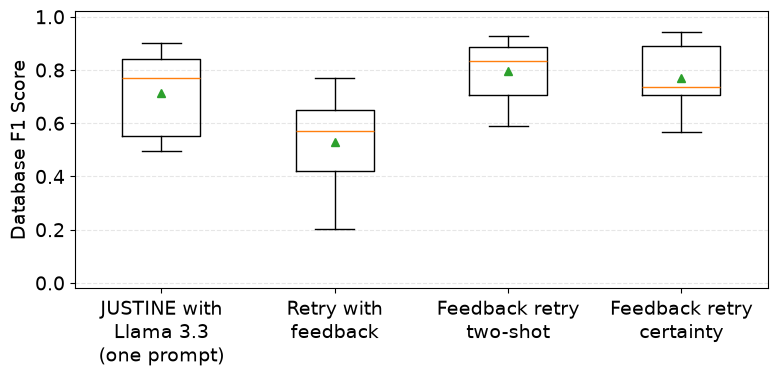

In [19]:
if len(experiments) > 1:
    loaded_results = {}
    for experiment in experiments:
        gs_results, result = load_results(
            os.path.join("results", f"{experiment}.json"),
            strategies_to_consider,
            require_same_results,
        )
        loaded_results[experiment] = result
else:
    gs_results, results = load_results(
        os.path.join("results", f"{experiments[0]}.json"),
        strategies_to_consider,
        require_same_results,
    )
    
# Call the desired plotting function here
# Example for a single experiment:
if len(experiments) == 1:
    # Call the function for the paper evaluation
    boxplot_one_parameter_all_strategies(gs_results, results, "0.2_0.375_0.5_0.5")
    # boxplot_one_strategy_by_database_source(
    #     os.path.join("results", f"{experiments[0]}.json"),
    #     "justine_3_3_retry_with_feedback",
    #     "0.2_0.375_0.5_0.5",
    # )
    # scatter_by_num_columns_tables(
    #     os.path.join("results", f"{experiments[0]}.json"),
    #     "justine_3_3_retry_with_feedback",
    #     "0.2_0.375_0.5_0.5",
    #     False,
    # )
    # scatter_by_percentage_numerical(
    #     os.path.join("results", f"{experiments[0]}.json"),
    #     "justine_3_3_retry_with_feedback",
    #     "0.2_0.375_0.5_0.5",
    # )
    # boxplot_parameters_all_strategies(gs_results, results)
    # barplot_all_strategies(gs_results, results, "0.2_0.375_0.5_0.5")
    # barplot_ratio_averages(results, "Llama3_finetuned_dc", "0.5")
# Example for multiple experiments (e.g., for comparing f1 scores):
if len(experiments) > 1:
    # Call the function for the paper evaluation
    boxplot_one_parameter_all_strategies_multiple_scores(gs_results, loaded_results, "0.2_0.375_0.5_0.5")
    # boxplot_one_parameter_one_strategy_multiple_experiments(
    #     gs_results,
    #     loaded_results,
    #     ["paper_evaluation_f1_score_null_strict", "batch_insertion_f1_score_null_strict", "shuffled_columns_f1_score_null_strict"],
    #     "justine_3_3_retry_with_feedback_two_shot",
    #     ["0.2_0.375_0.5_0.5", "0.8_0.2_0.375_0.5_0.5", "0.2_0.375_0.5_0.5"],
    # )